# Where the model fails on op_eq20 — a *length* failure, not an arithmetic one

Eval log `logs/eval/2026-07-13T19-05-50-00-00_task_aFFqVLSPWNMGzZD8eAceoZ.json`
(24 576 problems, 6 slices). Per-slice accuracy:

| slice | required ops | accuracy |
|---|---|---|
| op_le15 (in-dist) | ≤15 | **0.985** |
| op_eq15 | 15 | 0.360 |
| op_eq20 | 20 | **0.000** |
| op_eq21–23 | 21–23 | 0.000 |

**The model aces in-distribution but scores 0 on every op≥20 problem.** This notebook shows
*where* it fails, by running iGSM's `true_correct` (which checks the final answer **and every
intermediate calculation and every dependency edge**) on each generation.

**Finding:** the model's mod-23 arithmetic is **flawless on every step it actually produces**
(`wrong_cal = 0` in 100 % of cases). It fails because it **stops at ~14–15 operations and
answers prematurely** — it never reaches the 20-op depth an op_eq20 problem needs. The asked
quantity lives deeper in the dependency chain than the model's ~15-op ceiling, so the value
it outputs is for some intermediate parameter, not the answer. This is a **length /
planning-generalization gap** (the paper's Figure-3 model generalizes past op=15; ours does
not), **not** a precision or arithmetic failure.

In [1]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
os.chdir(str(ROOT)); sys.path.insert(0, str(ROOT))
import pickle
import matplotlib.pyplot as plt
C = pickle.load(open('notebooks/_eq20_diag.pkl','rb'))
EQ20, EQ15 = C['eq20'], C['eq15']
for sl, tag in [(EQ20,'op_eq20'), (EQ15,'op_eq15')]:
    print(f"{tag}: acc={sl['acc']:.4f}  required_ops={sl['n_ops']}  produced_ops={sl['sol_ops']}")


op_eq20: acc=0.0000  required_ops={20: 4096}  produced_ops={14: 2194, 15: 1847, 16: 28, 12: 3, 13: 8, 17: 2, 11: 1, 8: 1}
op_eq15: acc=0.3599  required_ops={15: 4096}  produced_ops={14: 2590, 15: 1488, 13: 17, 10: 1}


## 1. The model never reaches 20 operations

`parser.sol_op` = number of operations in the model's generated solution; `problem.n_op` =
how many the problem requires. For op_eq20 (requires 20), the model produces **14 ops (54 %)
or 15 ops (45 %)** — and *never* 20. For op_eq15 (requires 15) it reaches 15 only 36 % of
the time (those are exactly its correct answers); the other 63 % it stops at 14.

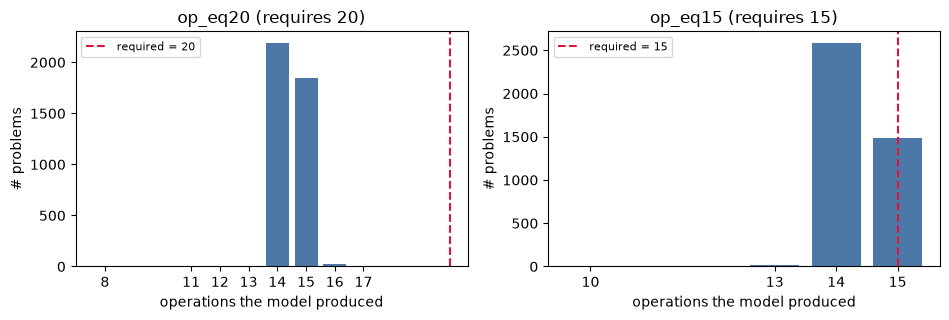

op_eq20 produced-ops: {14: 2194, 15: 1847, 16: 28, 12: 3, 13: 8, 17: 2, 11: 1, 8: 1}
op_eq15 produced-ops: {14: 2590, 15: 1488, 13: 17, 10: 1}


In [2]:
fig, axs = plt.subplots(1, 2, figsize=(9.6, 3.3))
for ax, sl, tag, req in [(axs[0], EQ20, 'op_eq20 (requires 20)', 20), (axs[1], EQ15, 'op_eq15 (requires 15)', 15)]:
    ks = sorted(sl['sol_ops']); vs = [sl['sol_ops'][k] for k in ks]
    ax.bar(ks, vs, color='#4C78A8')
    ax.axvline(req, color='crimson', ls='--', lw=1.5, label=f'required = {req}')
    ax.set_xlabel('operations the model produced'); ax.set_ylabel('# problems')
    ax.set_title(tag); ax.set_xticks(ks); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('op_eq20 produced-ops:', EQ20['sol_ops'])
print('op_eq15 produced-ops:', EQ15['sol_ops'])


## 2. The steps it *does* produce are arithmetically perfect

Among every premature-stop case, the count of **wrong mod-23 calculations in the steps the
model actually wrote** is zero — 100 % of the time, for both slices. The arithmetic engine
is sound; the model simply stops emitting steps before the chain is complete.

In [3]:
for sl, tag in [(EQ20,'op_eq20'), (EQ15,'op_eq15')]:
    w = sl['wc_stats']
    print(f"{tag}: among {w['n']} premature-stop solutions, mean wrong-calcs = {w['mean']}, "
          f"fraction with ZERO arithmetic errors = {w['frac_zero']:.4f}")


op_eq20: among 4084 premature-stop solutions, mean wrong-calcs = 0, fraction with ZERO arithmetic errors = 1.0000
op_eq15: among 2608 premature-stop solutions, mean wrong-calcs = 0, fraction with ZERO arithmetic errors = 1.0000


## 3. Concrete examples (model stops ~14/20 ops, all arithmetic correct, wrong answer)

Each example below shows the model's full generation. Every `a op b = r` is correct mod 23
(verify any: e.g. `12 + 12 = 1` ✓ since 24 mod 23 = 1; `16 * 12 = 8` ✓ since 192 mod 23 = 8).
The model defines ~14 parameters with perfect arithmetic, emits the answer sentinel, and stops
— ~6 operations short of the 20 the problem needs. The value it returns is for an intermediate
parameter, not the asked quantity (gold).

In [4]:
def show(ex):
    print('='*100)
    tag = 'CORRECT' if ex['correct'] else 'WRONG'
    print(f"[{tag}]  gold_answer={ex['gold']}  required_ops={ex['n_op']}  "
          f"model_did_ops={ex['sol_op']}  wrong_calcs={ex['wrong_cal']}   ({ex['mode']})")
    print('--- MODEL GENERATION ---')
    print(ex['gen'].strip())
    print()

# a few op_eq20 premature-stop examples
for ex in [e for e in EQ20['examples'] if 'premature stop' in e['mode']][:3]:
    show(ex)


[WRONG]  gold_answer=9  required_ops=20  model_did_ops=14  wrong_calcs=0   (premature stop (did 14 of 20 ops))
--- MODEL GENERATION ---
Define Sunnydale Primary's Theater Arts Classroom as Y; so Y = 12. Define Pine Ridge Elementary's Dance Studio as f; so f = Y = 12. Define Pine Ridge Elementary's Theater Arts Classroom as s; K = f + Y = 12 + 12 = 1; so s = 16 * K = 16 * 1 = 16. Define Pine Ridge Elementary's Visual Arts Studio as E; e = s + Y = 16 + 12 = 5; A = e + f = 5 + 12 = 17; so E = 13 + A = 13 + 17 = 7. Define Pine Ridge Elementary's Classroom as Z; B = E + f = 7 + 12 = 19; so Z = B + s = 19 + 16 = 12. Define Lakeview Elementary's Dance Studio as k; q = Z + f = 12 + 12 = 1; h = q + s = 1 + 16 = 17; so k = 17 + h = 17 + 17 = 11. Define Lakeview Elementary's Theater Arts Classroom as a; so a = 16 * Z = 16 * 12 = 8. Define Lakeview Elementary's Classroom as N; so N = a + k = 8 + 11 = 19.� 19

[WRONG]  gold_answer=18  required_ops=20  model_did_ops=14  wrong_calcs=0   (premature st

## 4. The contrast: op_eq15 when it *does* reach 15 ops → correct

On op_eq15, the 36 % of problems where the model sustains all 15 operations (with the same
zero-error arithmetic) are exactly its correct answers; the 63 % where it stops at 14 are
wrong. Same failure mode, just sometimes clearing the (lower) bar.

In [5]:
ex15 = [e for e in EQ15['examples'] if e['correct']]
if ex15:
    show(ex15[0])
else:
    print('(no fully-correct eq15 example in the cached subset; acc=0.36 means ~36% exist)')


[CORRECT]  gold_answer=21  required_ops=15  model_did_ops=15  wrong_calcs=0   (other/unknown)
--- MODEL GENERATION ---
Define Pigeon's Arterioles as K; so K = 9. Define Coastal Ecosystem's Woodpecker as T; so T = K = 9. Define Open Ocean's Creatures as E; so E = 0. Define Pigeon's Coronary Arteries as f; O = T + K = 9 + 9 = 18; so f = O + E = 18 + 0 = 18. Define Pigeon's Venules as L; A = E + K = 0 + 9 = 9; so L = 6 * A = 6 * 9 = 8. Define Pigeon's Organs as V; Z = L + K = 8 + 9 = 17; so V = Z + f = 17 + 18 = 12. Define Coastal Ecosystem's Pigeon as u; r = E - f = 0 - 18 = 5; so u = 14 + r = 14 + 5 = 19. Define Woodpecker's Organs as F; so F = 0. Define Coastal Ecosystem's Organs as l; h = u * V = 19 * 12 = 21; a = T * F = 9 * 0 = 0; so l = h + a = 21 + 0 = 21.� 21



## 5. Diagnosis

* **Not arithmetic.** Every step the model writes is correct mod 23 (0 wrong calcs in 100 % of
  cases). The precision/`inv_freq`/arithmetic hypotheses are ruled out — the reasoning engine
  works.
* **Not truncation.** Generations are ~286 tokens (cap was 2048); the model *chose* to emit
  the answer sentinel and stop.
* **It is a length / planning ceiling at ~14–15 ops** — the model's training `max_op=15`. It
  cannot emit a solution longer than its training distribution, so for op≥16 it always stops
  ~5–6 ops short and answers an intermediate value. This is exactly the Figure-3 cliff:
  op_le15 (≤15, within ceiling) 0.985 → op_eq15 (at the ceiling) 0.36 → op_eq≥16 (beyond) 0.0.

**Implication.** The paper's model generalizes past op=15; ours does not. The gap is length
generalization, which more training (we are at 8 k of 100 k steps), a higher training
`max_op`, or a curriculum may close. eval_loss (≈0.44, the entropy floor) gives no signal
here — track **generation accuracy on op_eq20** as the metric.